3. С использованием библиотеки ncurses реализовать движение курсора примерно по зависимости $y = A\cdot sin(\omega x)$. Параметры $A, \omega$ подобрать в программе.

In [ ]:
format ELF64
public _start

extrn initscr
extrn endwin
extrn move
extrn addch
extrn refresh
extrn clear
extrn getmaxx
extrn getmaxy
extrn usleep
extrn curs_set
extrn sin
extrn exit

section '.data' writable
    omega       dq 0.1      ; Плавность волны
    factor_3    dq 3.0      ; Амплитуда (высота/3)
    factor_2    dq 2.0      ; Центр (высота/2)
    delay       dq 50000    
    
    cursor_char dq '#'      ; Символ курсора
    empty_char  dq ' '      

section '.bss' writable
    max_x       dq ?
    max_y       dq ?
    pos_x       dq 0
    pos_y       dq 0
    
    amplitude   dq ?
    center_y    dq ?
    win_ptr     dq ?

section '.text' executable

_start:
    and     rsp, -16

    call    initscr
    mov     [win_ptr], rax
    
    mov     rdi, 0
    call    curs_set

    mov     rdi, [win_ptr]
    call    getmaxx
    dec     rax
    mov     [max_x], rax

    mov     rdi, [win_ptr]
    call    getmaxy
    dec     rax
    mov     [max_y], rax
    
    ; Расчет геометрии
    cvtsi2sd xmm0, [max_y]
    divsd    xmm0, [factor_2]
    movsd    [center_y], xmm0
    
    cvtsi2sd xmm0, [max_y]
    divsd    xmm0, [factor_3]
    movsd    [amplitude], xmm0

    mov     qword [pos_x], 0

.loop:
    ; 1. вычисляем Y для текущего X
    cvtsi2sd xmm0, [pos_x]
    mulsd    xmm0, [omega]
    call    sin
    mulsd    xmm0, [amplitude]
    addsd    xmm0, [center_y]
    cvttsd2si rax, xmm0
    mov      [pos_y], rax

    ; 2.  отрисовка курсора
    mov     rdi, [pos_y]
    mov     rsi, [pos_x]
    call    move
    
    mov     rdi, [cursor_char]
    call    addch
    
    call    refresh

    ; 3. ждем (чтобы увидеть курсор в этой точке)
    mov     rdi, [delay]
    call    usleep

    ; 4. стираем курсор (в той же точке)
    mov     rdi, [pos_y]
    mov     rsi, [pos_x]
    call    move
    
    mov     rdi, [empty_char] 
    call    addch

    ; 5. двигаем координату X вперед
    inc     qword [pos_x]
    
    ; Проверка границ
    mov     rax, [pos_x]
    cmp     rax, [max_x]
    jl      .loop

    ; Если дошли до края экрана -> сброс X в 0
    mov     qword [pos_x], 0
    jmp     .loop

    call    endwin
    xor     rdi, rdi
    call    exit

In [ ]:
Для запуска:
fasm sine.asm sine.o
ld -o sine sine.o -dynamic-linker /lib64/ld-linux-x86-64.so.2 -lncurses -lm -lc
./sine

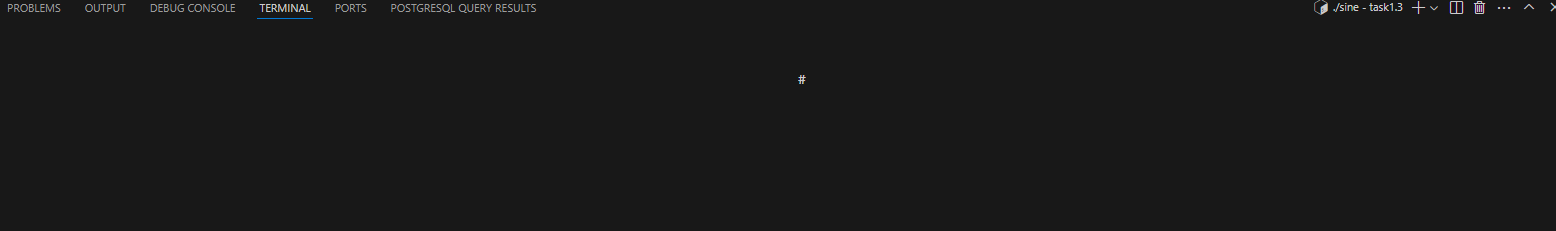

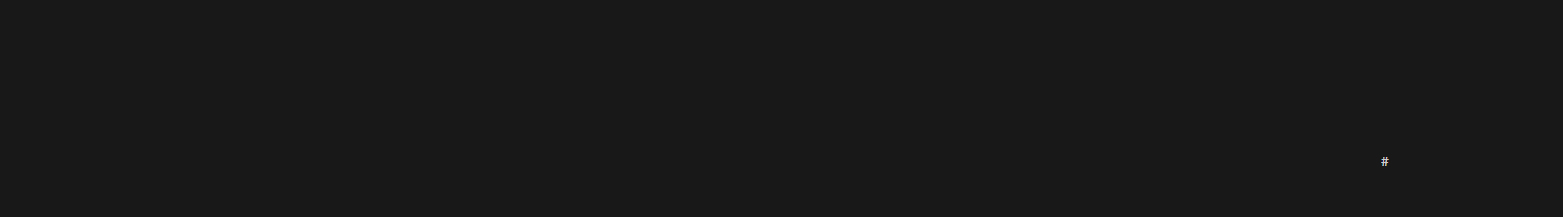

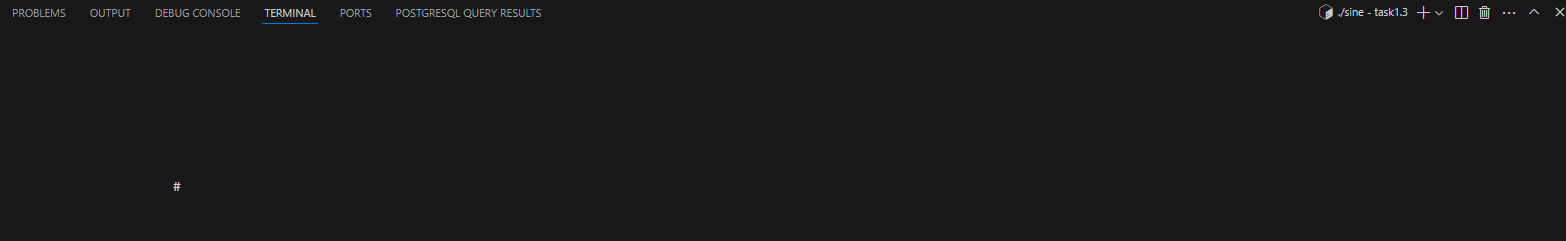

3. В программе на ассемблере заполнить массив числами 1, 2, 3,... в количестве $N$ (вводится параметром командной строки), создать два дочерних процесса (clone). Один дочерний процесс должен увеличить на единицу все четные числа, другой - уменьшить на единицу все нечетные. По окончанию работы дочерных процессов родительский процесс должен вывести получившийся массив на экран.

In [ ]:
format ELF64
public _start

extrn printf
extrn atoi
extrn exit
extrn fflush

SYS_MMAP    equ 9
SYS_CLONE   equ 56
SYS_WAIT4   equ 61
SYS_EXIT    equ 60

PROT_READ   equ 1
PROT_WRITE  equ 2
MAP_SHARED  equ 1
MAP_ANON    equ 32
SIGCHLD     equ 17

section '.data' writable
    msg_usage   db ":./clone <N>", 10, 0
    
    msg_init    db "Начальный массив: ", 0
    msg_ch1     db "Child 1 ( чет  -> +1 ): ", 0
    msg_ch2     db "Child 2 (нечет -> -1 ): ", 0
    msg_final   db "Конечный массив:   ", 0
    
    fmt_num     db "%d ", 0
    fmt_newline db 10, 0
    
    N           dq 0
    array_ptr   dq 0

section '.text' executable

_start:
    pop     rcx             ; RCX = argc
    cmp     rcx, 2          ; >= 2 (имя + число)
    jl      .print_usage

    mov     rdi, [rsp + 8]  ; RDI = строка argv[1]
    
    sub     rsp, 8 
    call    atoi
    add     rsp, 8
    
    mov     [N], rax
    cmp     rax, 0
    jle     .exit_global    ; Если N <= 0, выход

    ; Выделение общей памяти (mmap) 
    mov     rax, SYS_MMAP
    mov     rdi, 0
    mov     rsi, [N]
    imul    rsi, 4          ; Размер в байтах
    mov     rdx, PROT_READ + PROT_WRITE
    mov     r10, MAP_SHARED + MAP_ANON
    mov     r8, -1
    mov     r9, 0
    syscall
    
    cmp     rax, 0
    jl      .exit_global
    mov     [array_ptr], rax

    ; Заполнение массива 1..N 
    mov     rcx, 0
    mov     rbx, [array_ptr]
.fill_loop:
    cmp     rcx, [N]
    jge     .fill_done
    mov     rax, rcx
    inc     rax
    mov     [rbx + rcx*4], eax
    inc     rcx
    jmp     .fill_loop
.fill_done:

    mov     rdi, msg_init
    mov     rsi, [array_ptr]
    mov     rdx, [N]
    call    print_array_safe

    ; Запуск Child 1 
    mov     rax, SYS_CLONE
    mov     rdi, SIGCHLD
    mov     rsi, 0       
    syscall

    cmp     rax, 0
    je      .child_even   
    
    ; Запуск Child 2 (из родителя) 
    mov     rax, SYS_CLONE
    mov     rdi, SIGCHLD
    mov     rsi, 0
    syscall

    cmp     rax, 0
    je      .child_odd     

    ; Ждем первого
    mov     rax, SYS_WAIT4
    mov     rdi, -1
    mov     rsi, 0
    mov     rdx, 0
    mov     r10, 0
    syscall

    ; Ждем второго
    mov     rax, SYS_WAIT4
    mov     rdi, -1
    mov     rsi, 0
    mov     rdx, 0
    mov     r10, 0
    syscall

    ; Вывод финала
    mov     rdi, msg_final
    mov     rsi, [array_ptr]
    mov     rdx, [N]
    call    print_array_safe

.exit_global:
    mov     rdi, 0
    call    exit           

; Логика первого, с четным
.child_even:
    mov     rcx, 0
    mov     rbx, [array_ptr]
    mov     r12, [N]
.ce_loop:
    cmp     rcx, r12
    jge     .ce_print

    mov     eax, [rbx + rcx*4]
    test    eax, 1
    jnz     .ce_next        ; Если нечетное, пропуск
    inc     eax
    mov     [rbx + rcx*4], eax
.ce_next:
    inc     rcx
    jmp     .ce_loop
.ce_print:
    mov     rdi, msg_ch1
    mov     rsi, [array_ptr]
    mov     rdx, [N]
    call    print_array_safe
    
    mov     rdi, 0
    call    exit

; Логика второго, с нечетным
.child_odd:
    mov     rcx, 0
    mov     rbx, [array_ptr]
    mov     r12, [N]
.co_loop:
    cmp     rcx, r12
    jge     .co_print

    mov     eax, [rbx + rcx*4]
    test    eax, 1
    jz      .co_next        ; Если четное, пропуск
    dec     eax
    mov     [rbx + rcx*4], eax
.co_next:
    inc     rcx
    jmp     .co_loop
.co_print:
    mov     rdi, msg_ch2
    mov     rsi, [array_ptr]
    mov     rdx, [N]
    call    print_array_safe

    mov     rdi, 0
    call    exit

.print_usage:
; Вывод ошибки
    and     rsp, -16
    mov     rdi, msg_usage
    xor     rax, rax
    call    printf
    mov     rdi, 1
    call    exit

print_array_safe:
    push    rbp
    mov     rbp, rsp
    ; Сохраняем регистры
    push    rbx
    push    r12
    push    r13
    push    r14
    
    sub     rsp, 8

    mov     r13, rdi        ; Строка
    mov     rbx, rsi        ; Массив
    mov     r12, rdx        ; N

    ; Печать заголовка
    mov     rdi, r13
    xor     rax, rax
    call    printf

    mov     r14, 0          ; i
.pr_loop:
    cmp     r14, r12
    jge     .pr_done

    mov     rdi, fmt_num
    movsxd  rsi, dword [rbx + r14*4]
    xor     rax, rax
    call    printf

    inc     r14
    jmp     .pr_loop

.pr_done:
    mov     rdi, fmt_newline
    xor     rax, rax
    call    printf
    
    mov     rdi, 0
    call    fflush

    add     rsp, 8      
    
    pop     r14
    pop     r13
    pop     r12
    pop     rbx
    leave
    ret

In [ ]:
Для запуска:
fasm clone.asm clone.o
ld -o clone clone.o -dynamic-linker /lib64/ld-linux-x86-64.so.2 -lc
./clone 12

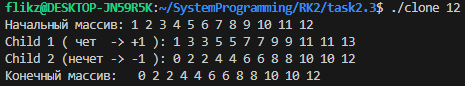